### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import Callback
import joblib

### Data Preparation

#### Data Loading

In [2]:
# https://drive.google.com/file/d/1QGt1kyS8vEXuwVwW-RK49ijy9BehzDZ-/view?usp=drive_link
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1QGt1kyS8vEXuwVwW-RK49ijy9BehzDZ-")
df

,order_id,user_id,order_date,time,order_hour_of_day,product_name,quantity,price,category,product_id,revenue,month_year
0,1000,341,2024-09-04,15:43:00,15,Wheat Flour,1,333.44,Grains & Staples,457,333.44,2024-09
1,1000,341,2024-09-04,15:43:00,15,Dishwashing Liquid,2,405.92,Household,745,811.84,2024-09
2,1000,341,2024-09-04,15:43:00,15,Pastry,2,114.15,Bakery,849,228.30,2024-09
3,1000,341,2024-09-04,15:43:00,15,Marker,2,171.33,Stationery,599,342.66,2024-09
4,1001,324,2024-03-07,8:45:00,8,Saree,2,41.16,Clothing,329,82.32,2024-03
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2989,271,2024-11-29,14:22:00,14,Shirt,1,485.90,Clothing,872,485.90,2024-11
9996,2989,271,2024-11-29,14:22:00,14,Spinach,3,434.44,Fruits & Vegetables,654,1303.32,2024-11
9997,2989,271,2024-11-29,14:22:00,14,Popcorn,3,146.66,Snacks,593,439.98,2024-11
9998,2990,400,2024-02-09,20:08:00,20,Chips,2,362.99,Snacks,108,725.98,2024-02


#### Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   order_date         10000 non-null  object 
 3   time               10000 non-null  object 
 4   order_hour_of_day  10000 non-null  int64  
 5   product_name       10000 non-null  object 
 6   quantity           10000 non-null  int64  
 7   price              10000 non-null  float64
 8   category           10000 non-null  object 
 9   product_id         10000 non-null  int64  
 10  revenue            10000 non-null  float64
 11  month_year         10000 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 937.6+ KB


In [4]:
df["order_date"] = pd.to_datetime(df["order_date"])
daily_df = df.groupby("order_date").agg({"revenue": "sum"}).reset_index()
daily_df

,order_date,revenue
0,2024-01-01,9376.41
1,2024-01-02,22642.00
2,2024-01-03,12068.19
3,2024-01-04,7565.54
4,2024-01-05,15866.89
...,...,...
358,2024-12-27,7044.65
359,2024-12-28,21432.40
360,2024-12-29,13574.16
361,2024-12-30,20240.89


In [5]:
dates = daily_df["order_date"].values
revenue = daily_df["revenue"].values

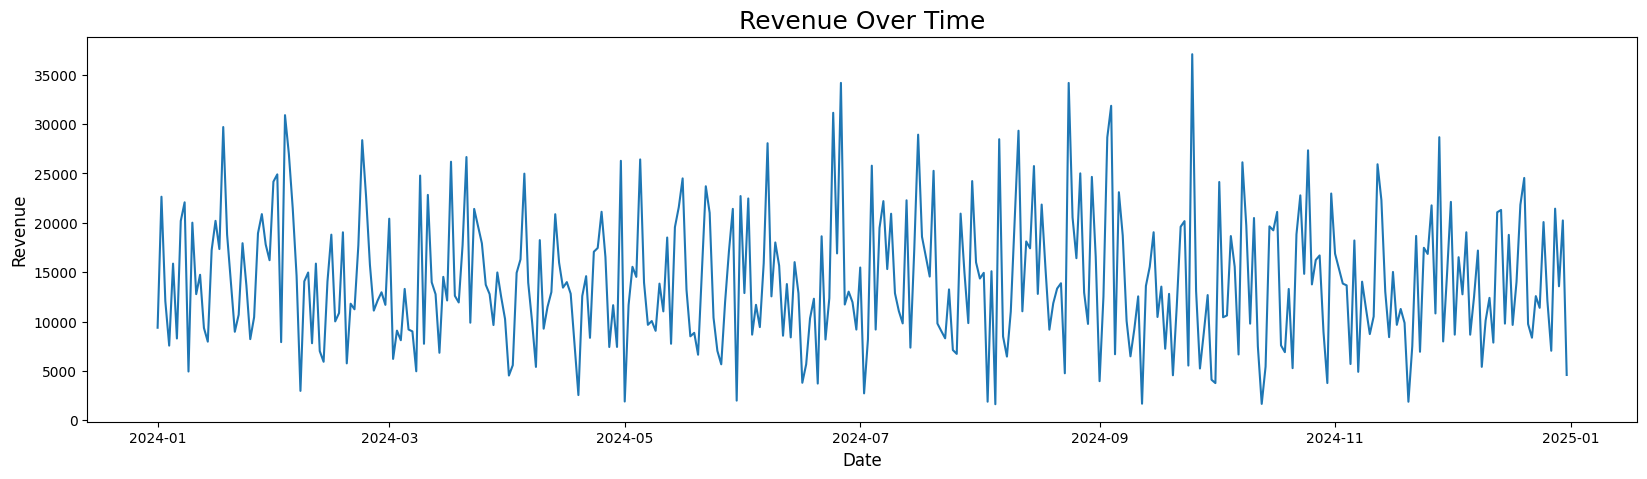

In [6]:
plt.figure(figsize=(20,5))
plt.plot(dates, revenue)
plt.title("Revenue Over Time", fontsize=18)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.show()

### Time-Series Model

#### Training, Validation, and Testing Split

In [7]:
TOTAL_SIZE = len(revenue)
TRAIN_SIZE = int(0.7 * TOTAL_SIZE)
VAL_SIZE = int(0.15 * TOTAL_SIZE)
TEST_SIZE = TOTAL_SIZE - TRAIN_SIZE - VAL_SIZE

train_data = revenue[:TRAIN_SIZE]
val_data = revenue[TRAIN_SIZE:TRAIN_SIZE+VAL_SIZE]
test_data = revenue[TRAIN_SIZE+VAL_SIZE:]

#### Data Scaling

In [8]:
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data.reshape(-1, 1))
val_data = scaler.transform(val_data.reshape(-1, 1))
test_data = scaler.transform(test_data.reshape(-1, 1))

#### Data Windowing

In [9]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[-1:]))
    return ds.batch(batch_size).prefetch(1)

#### Custom Callback

In [10]:
class CustomEarlyStopping(Callback):
  def __init__(self, target_mae):
    super().__init__()
    self.target_mae = target_mae

  def on_epoch_end(self, epoch, logs=None):
    if logs and logs.get("mae") <= self.target_mae:
      print(f"\nThe targetted MAE has been achieved. Stopping training process.")
      self.model.stop_training = True

#### Model Training

In [11]:
WINDOW_SIZE=7
NUM_FEATURES=1
BATCH_SIZE=16
SHUFFLE_BUFFER=1000

train_set = windowed_dataset(train_data, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, shuffle_buffer=SHUFFLE_BUFFER)
val_set = windowed_dataset(val_data, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, shuffle_buffer=SHUFFLE_BUFFER)
test_set = windowed_dataset(test_data, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, shuffle_buffer=SHUFFLE_BUFFER)

inputs = Input(shape=(WINDOW_SIZE, NUM_FEATURES))
x = LSTM(60, return_sequences=True)(inputs)
x = LSTM(60)(x)
x = Dense(30, activation="relu")(x)
x = Dense(10, activation="relu")(x)
outputs = Dense(1)(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(loss=Huber(), optimizer="adam", metrics=["mae"])

history = model.fit(train_set, validation_data=val_set, epochs=10, callbacks=[CustomEarlyStopping(target_mae=0.02)])

Epoch 1/10
     13/Unknown 5s 9ms/step - loss: 0.0771 - mae: 0.3285

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0506 - mae: 0.2514 - val_loss: 0.0309 - val_mae: 0.2022
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0255 - mae: 0.1787 - val_loss: 0.0269 - val_mae: 0.1888
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0233 - mae: 0.1751 - val_loss: 0.0265 - val_mae: 0.1881
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0226 - mae: 0.1677 - val_loss: 0.0263 - val_mae: 0.1869
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0225 - mae: 0.1700 - val_loss: 0.0261 - val_mae: 0.1869
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0227 - mae: 0.1676 - val_loss: 0.0263 - val_mae: 0.1879
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0225 - mae: 0.1700 - val_loss: 0.0261 - val_mae: 0.1863
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0223 - mae: 0.1690 - val_loss: 0.0263 - val_mae: 0.1869
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0231 - mae: 0.

In [12]:
loss, mae = model.evaluate(test_set)
print(f"Testing Loss: {loss}")
print(f"Testing MAE: {mae}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0164 - mae: 0.1509
Testing Loss: 0.016390420496463776
Testing MAE: 0.15089412033557892


### Inference

#### Next-Day Revenue Prediction

In [13]:
revenues = [
    50000,
    70000,
    30000,
    100000,
    40000,
    60000,
    30000
]

revenues = np.array(revenues).reshape(-1, 1)
scaled_revenues = scaler.fit_transform(revenues)

input = scaled_revenues.reshape(1, WINDOW_SIZE, 1) # (batch, timestep, feature)

scaled_prediction = model.predict(input, verbose=None)
prediction = scaler.inverse_transform(scaled_prediction)
prediction = np.round(prediction, -3)

print(f"Predicted revenue for next day: {int(prediction[0][0])}")

Predicted revenue for next day: 55000


#### End-of-Week Revenue Prediction

In [14]:
DAYS=7

revenues = [
    80000,
    120000,
    50000,
    60000,
    100000,
    70000,
    150000
]

revenues = np.array(revenues).reshape(-1, 1)
scaled_revenues = scaler.fit_transform(revenues)

for _ in range(DAYS):
    input = scaled_revenues.reshape(1, WINDOW_SIZE, 1)

    scaled_prediction = model.predict(input, verbose=None)
    prediction = scaler.inverse_transform(scaled_prediction)
    prediction = int(np.round(prediction[0][0], -3))

    revenues = np.append(revenues, prediction)
    revenues = revenues[1:]
    revenues = np.array(revenues).reshape(-1, 1)

    scaled_revenues = scaler.transform(revenues)

print(f"Predicted revenue for 7 days later: {revenues[-1][0]}")

Predicted revenue for 7 days later: 89000


### Save Model and Scaler

In [15]:
save_path = "saved_model/"
model.export(save_path)

Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136082688071952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688074256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688074640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688072528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688074064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688075408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688074448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688072336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688075216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688073104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136082688075600: TensorSp

In [16]:
scaler_path = "revenue_scaler.pkl"
joblib.dump(scaler, scaler_path)

['revenue_scaler.pkl']